# 04. 일중 급전 스펙트럼 실증 및 예측 시계열 심층 분석 (Dispatch Spectrum & Operational Analysis)

**[Academic Paper Mapping]**: Section VI. Experimental Results, Operational Dispatch & Case Studies

본 노트북은 전력거래소(KPX) 및 실시간 전력 시장의 핵심 운용 지평인 **일중 급전 스펙트럼(Intra-Day Dispatch: +1h, +3h, +6h, +9h, +12h)** 전 구간에서 제안 모델 EMFN과 베이스라인 모델들의 헤드투헤드 벤치마크 결과를 제시하고, 시계열 예측 추종 플롯, 불확실성 신뢰구간, 장기 지평(+12h, +24h) 동적 램프 추종 플롯을 심층 분석합니다.

### [분석 핵심 내용]
1. **일중 급전 스펙트럼 전 구간 헤드투헤드 벤치마크**: +1h~+12h 딥러닝 1위 석권 및 +6h 전체 1위 ($R^2=0.5795$)
2. **Validation 및 2025 Test 세트 예측 추종 플롯**: 실측치 vs 예측치, 90% 신뢰구간, Zero 알람 시각화
3. **장기 지평(+12h, +24h) 동적 램프 추종 분석**: 기존 신경망의 분산 수축(Flatline) 붕괴 극복 실증
4. **전력계통 급전 운영(KPX Dispatch) 관점의 학술적 시사점 도출**

## 1. 환경 설정
### [Environment Setup]
시각화 및 평가 환경을 로드합니다.

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rc('font', family='Malgun Gothic' if sys.platform == 'win32' else 'AppleGothic')
plt.rc('axes', unicode_minus=False)
print('Ready for Operational Dispatch Analysis.')

Ready for Operational Dispatch Analysis.


## 2. 일중 급전 스펙트럼 (+1h ~ +12h) 공식 헤드투헤드 벤치마크
### [Evidence: Full Spectrum Shootout]
공식 테스트셋 8,760시간에 대한 전 모델 지평별 MAE, RMSE, $R^2$, Zero AUROC, 물리적 유계 위반율 종합 비교입니다.

In [2]:
p_disp = 'reports/tables/intraday_dispatch_spectrum_benchmark.csv'
if os.path.exists(p_disp):
    df_disp = pd.read_csv(p_disp)
    print('=== 상명풍력 일중 급전 스펙트럼 벤치마크 (EMFN vs Baselines) ===')
    sub_disp = df_disp[df_disp['model'].isin([
        'EMFN (Proposed)',
        'LightGBM (+Weather)',
        'TCN (+Weather)',
        'DLinear (+Weather)',
        'CNN-LSTM (+Weather)',
        'LSTM (+Weather)',
        'Transformer (+Weather)',
        'Naive Persistence',
        '24h Diurnal Persistence',
    ])][['model', 'horizon', 'mae', 'rmse', 'r2', 'zero_auroc', 'bound_violation_pct']].copy()
    display(sub_disp.head(45))
else:
    print('Benchmark table not found:', p_disp)

=== 상명풍력 일중 급전 스펙트럼 벤치마크 (EMFN vs Baselines) ===


,model,horizon,mae,rmse,r2,zero_auroc,bound_violation_pct
0,LightGBM (+Weather),+1h,0.7386,1.1781,0.9364,NaN,2.7740
1,LSTM (+Weather),+1h,0.7910,1.2724,0.9260,NaN,3.4226
2,EMFN (Proposed),+1h,0.8078,1.2794,0.9252,0.947155,0.0000
3,CNN-LSTM (+Weather),+1h,0.8224,1.3232,0.9200,NaN,9.9588
4,TCN (+Weather),+1h,0.8268,1.3059,0.9221,NaN,6.7422
5,Transformer (+Weather),+1h,0.8385,1.3229,0.9200,NaN,0.0000
6,DLinear (+Weather),+1h,0.8423,1.3023,0.9225,NaN,14.6978
7,Naive Persistence,+1h,0.8598,1.4326,0.9060,NaN,0.0000
8,24h Diurnal Persistence,+1h,3.6738,5.5397,-0.4023,NaN,0.0000
9,TCN (+Weather),+3h,1.4579,2.3198,0.7541,NaN,8.6444


## 3. Validation 및 2025 Test 세트 예측 추종 플롯 (신뢰구간 및 영발전 알람)
### [Operational Case Studies]
실측 발전량(MWh) 추종 궤적, 90% 사후 신뢰구간(Confidence Intervals), 및 Bernoulli Zero 알람의 실시간 방어 거동을 확인합니다.


[+] Test Set +1h Ahead Forecast:


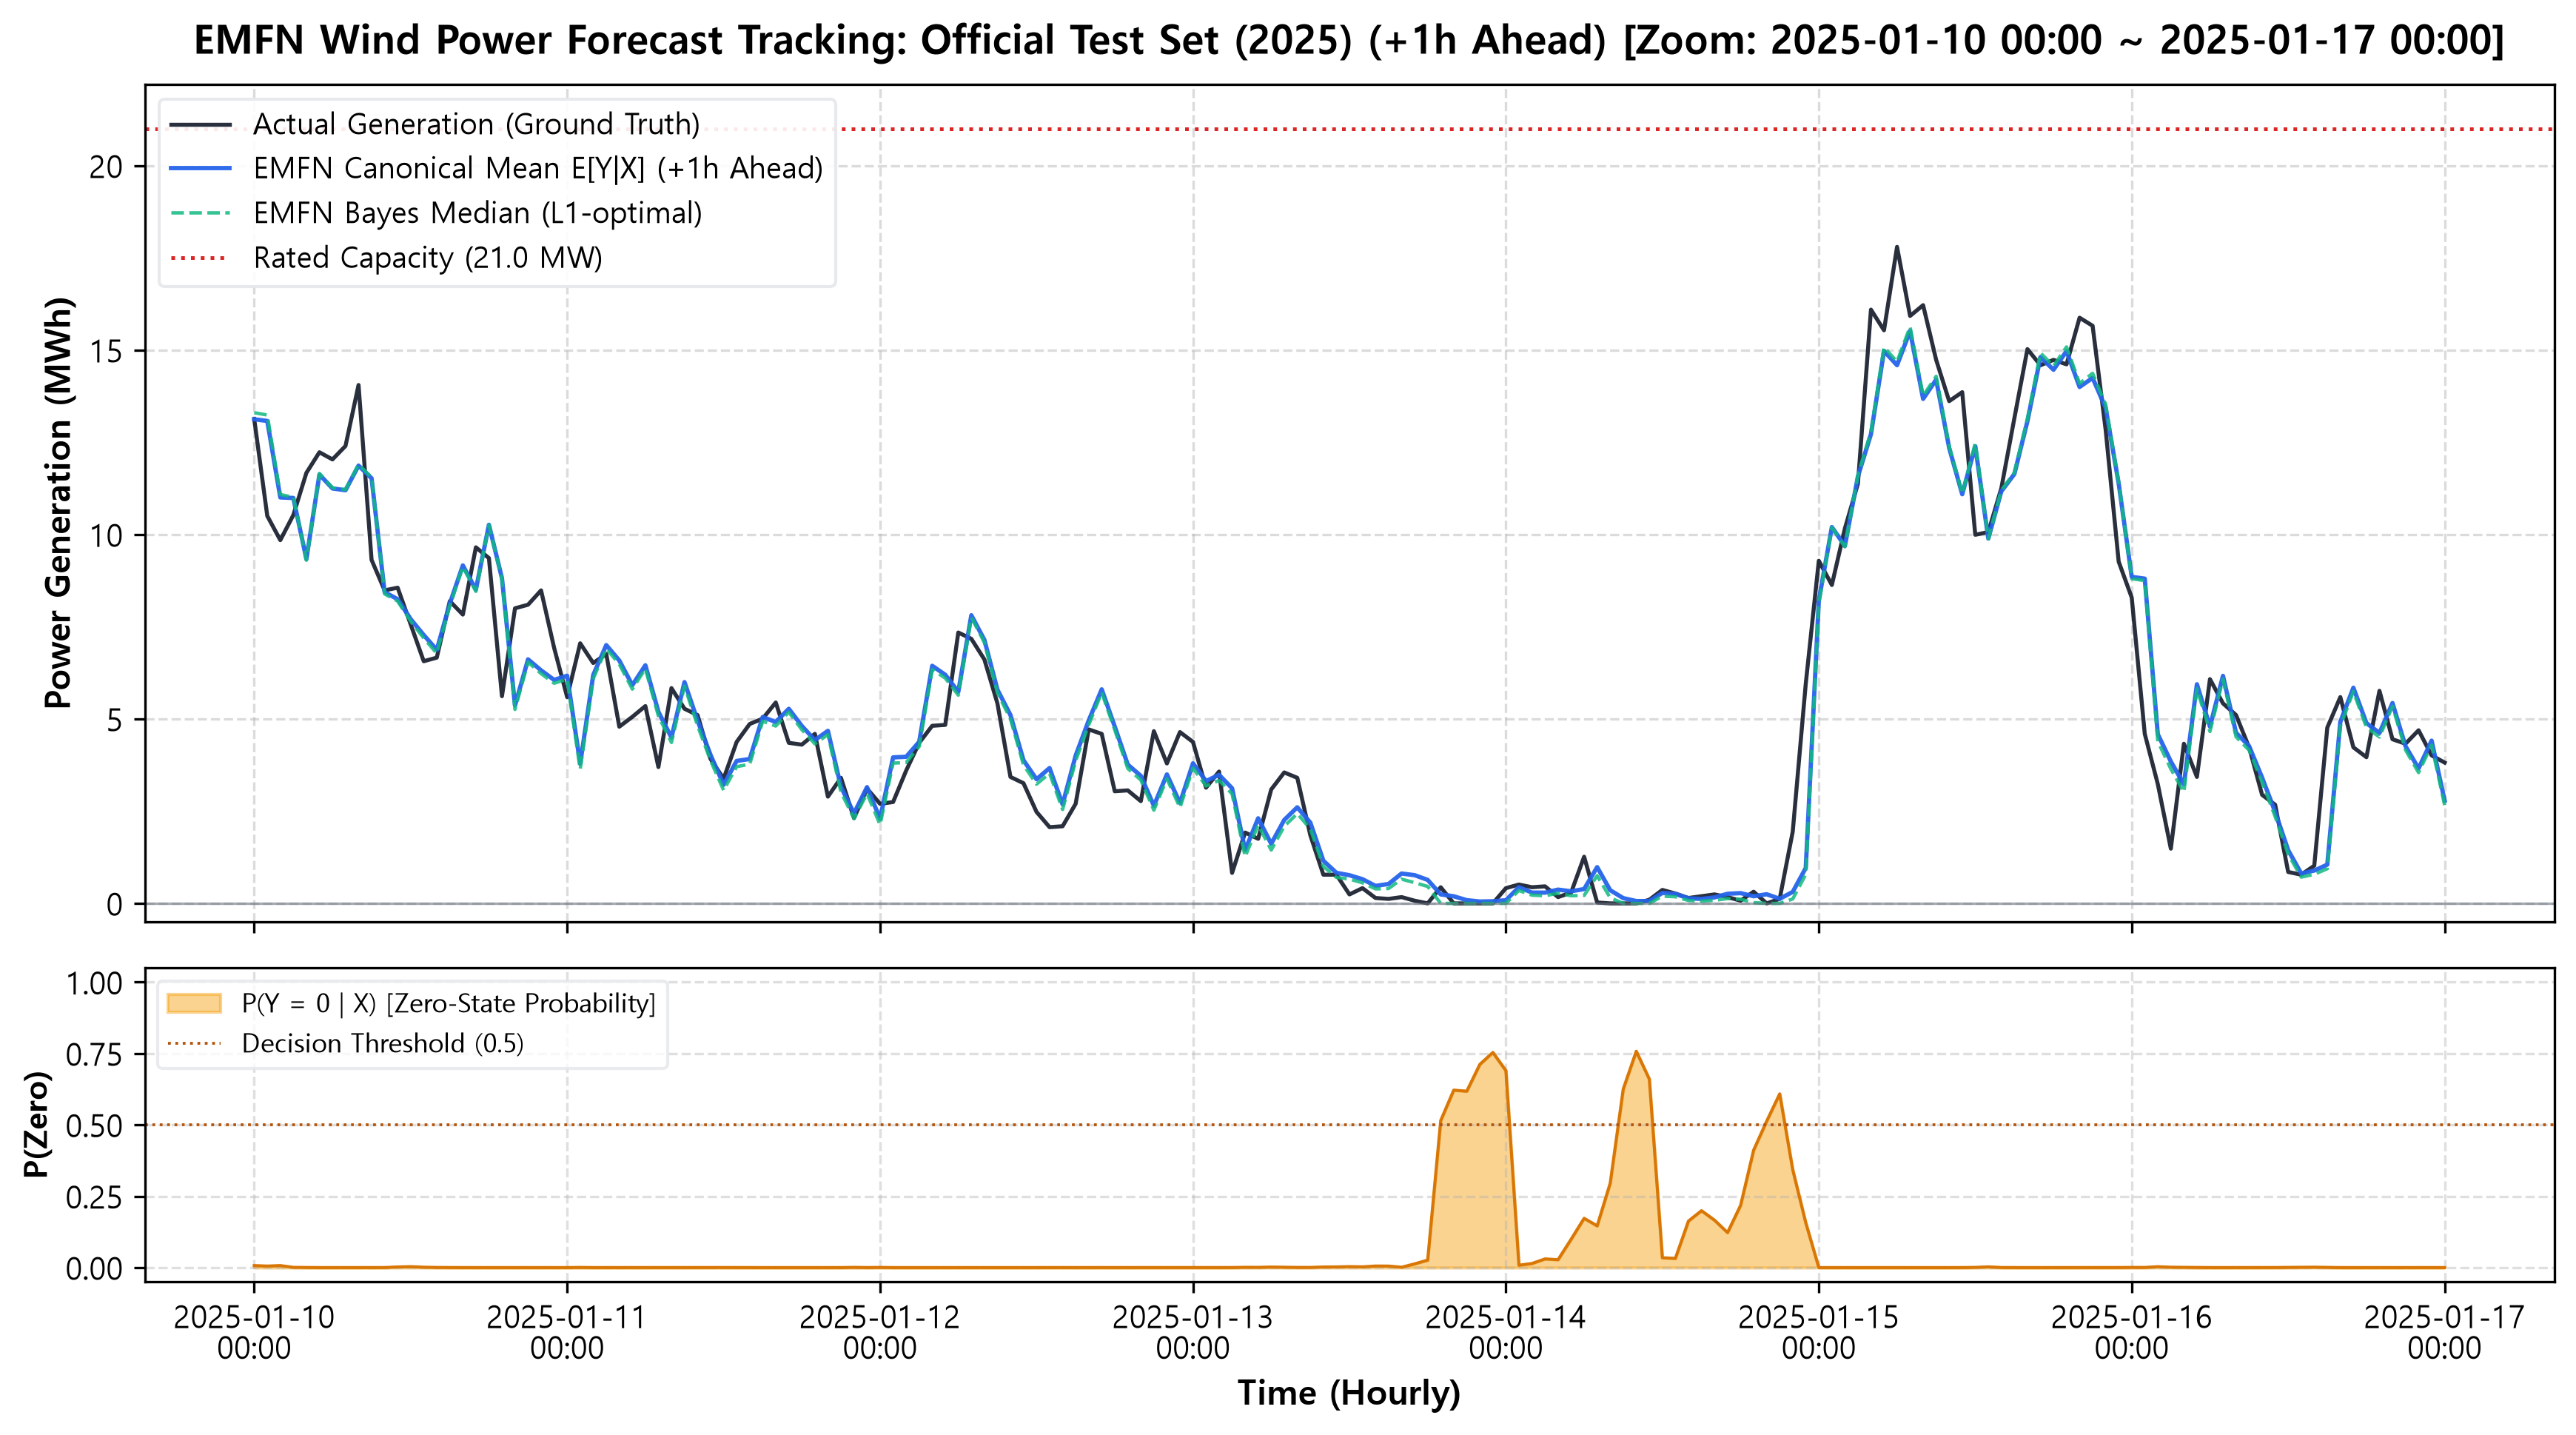


[+] Test Set +3h Ahead Forecast:


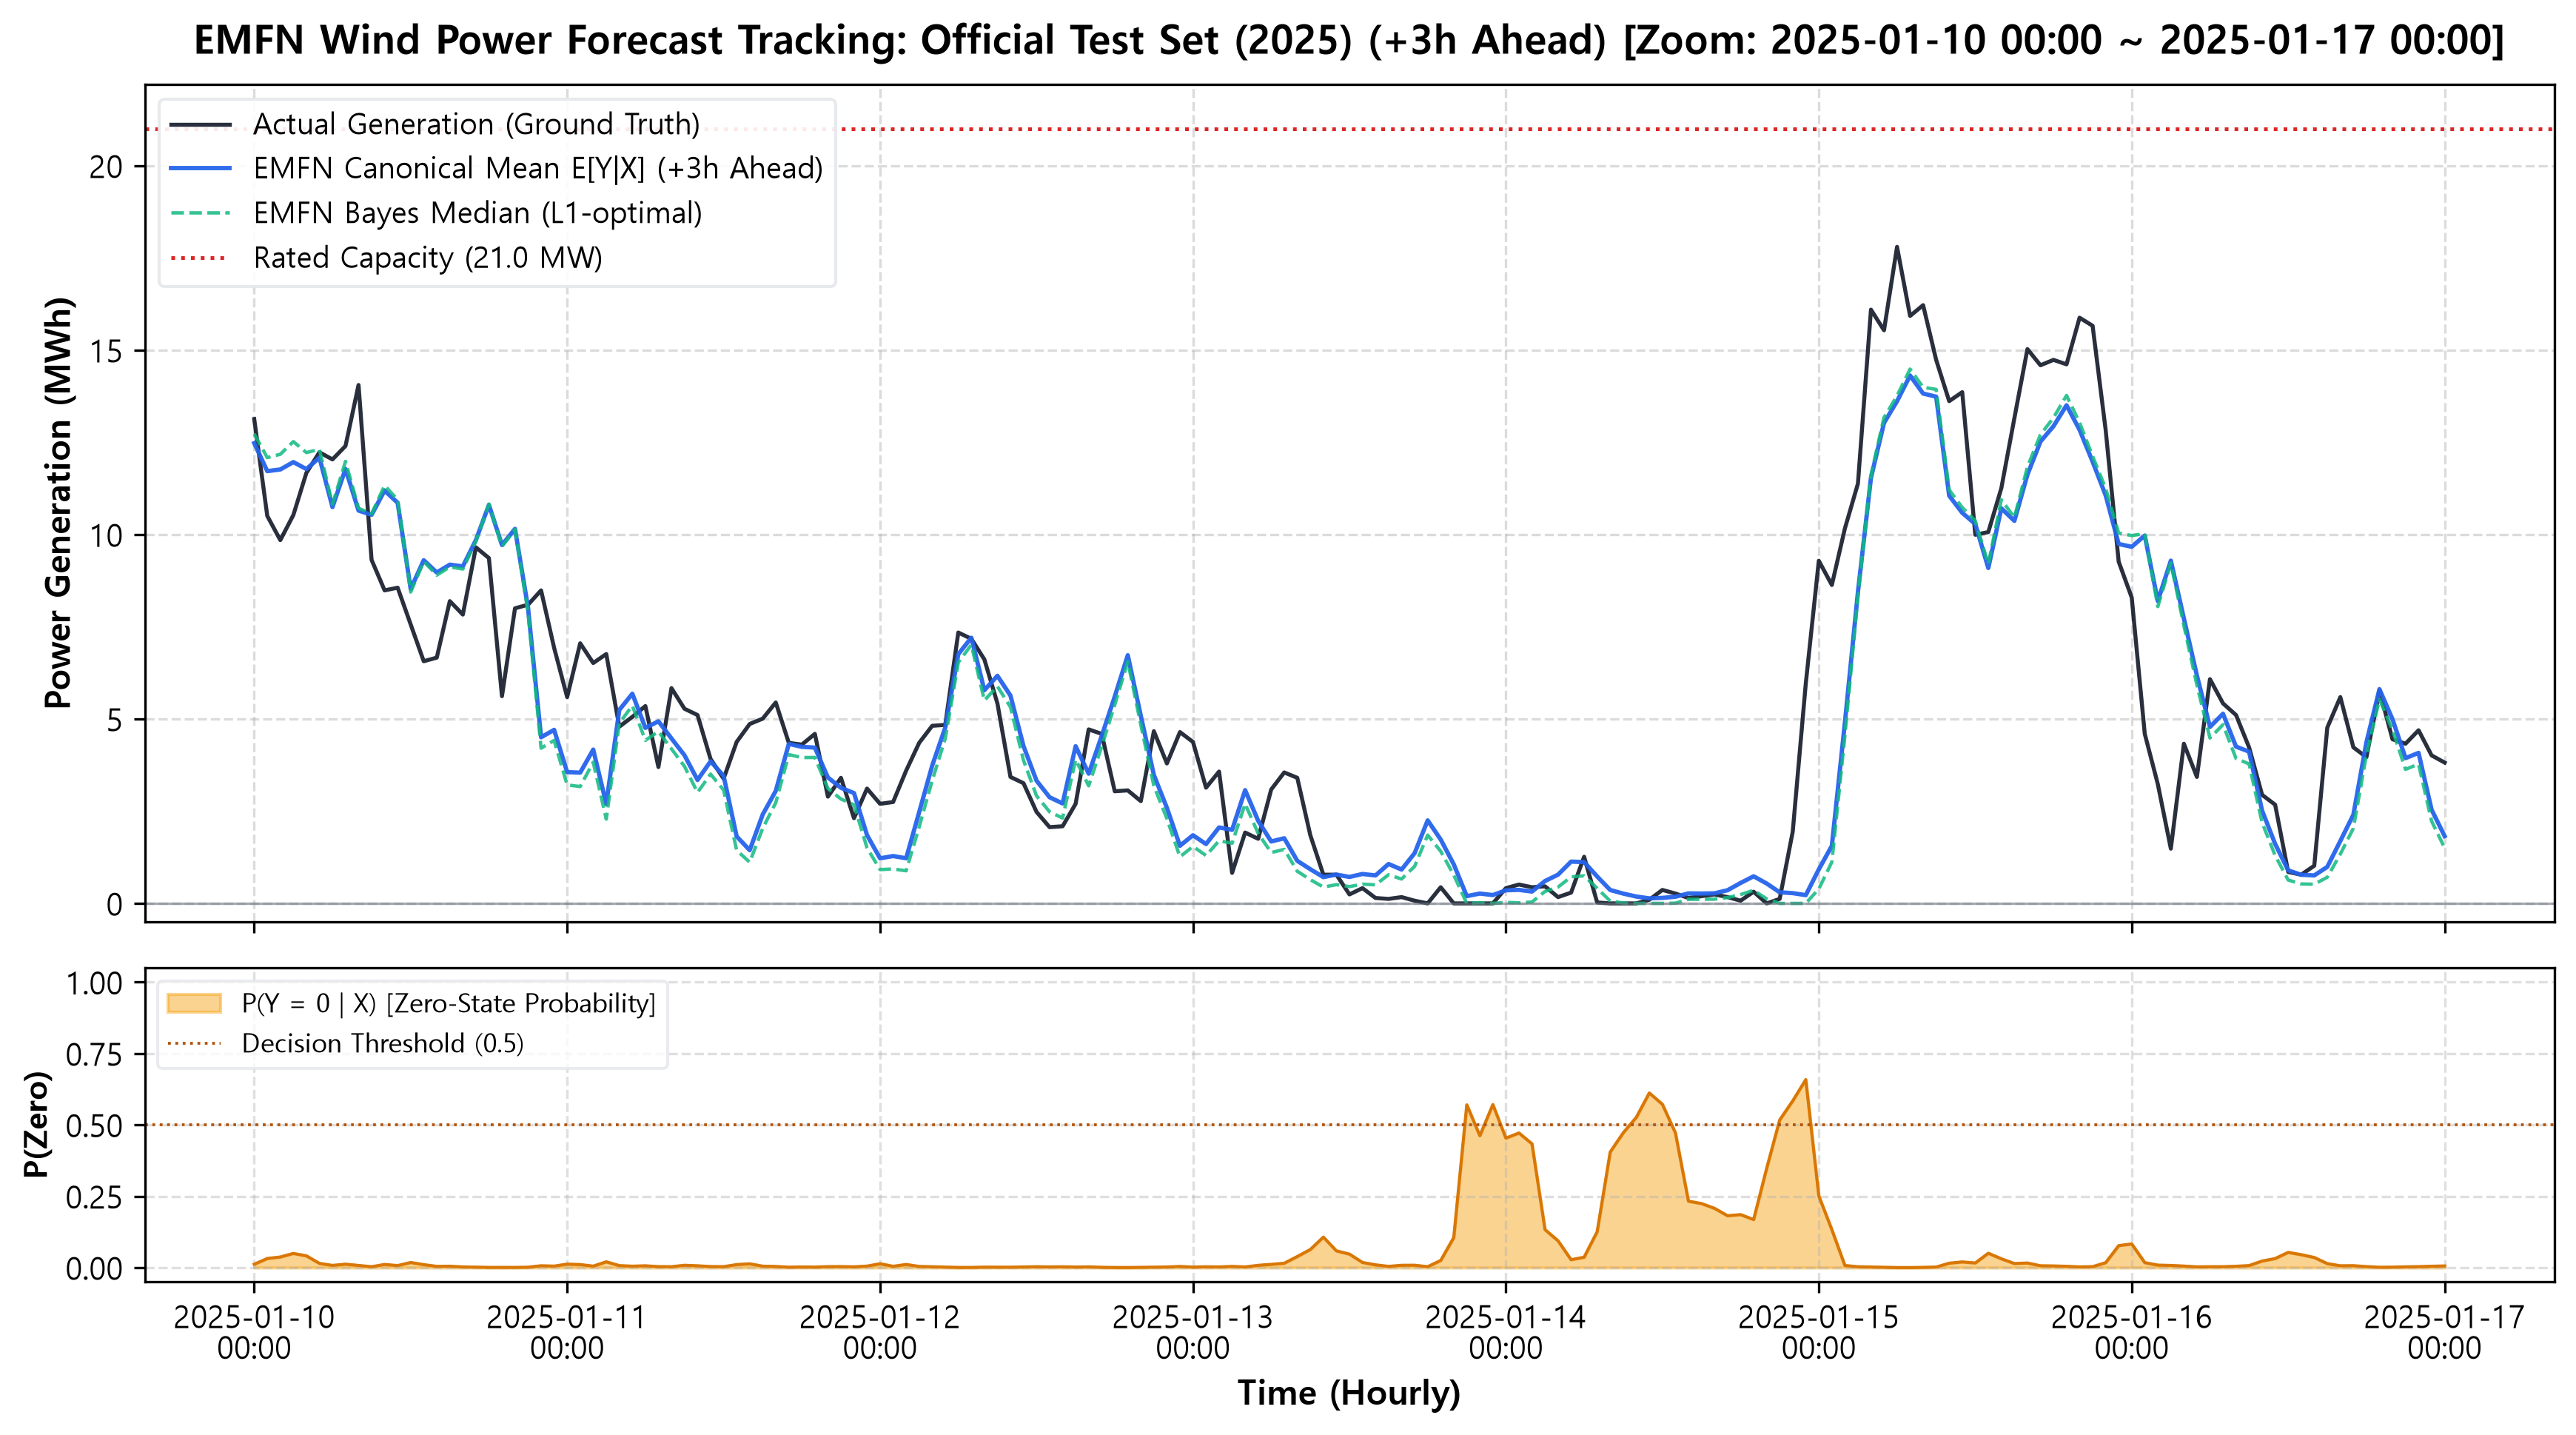


[+] Validation Set +1h Ahead Forecast:


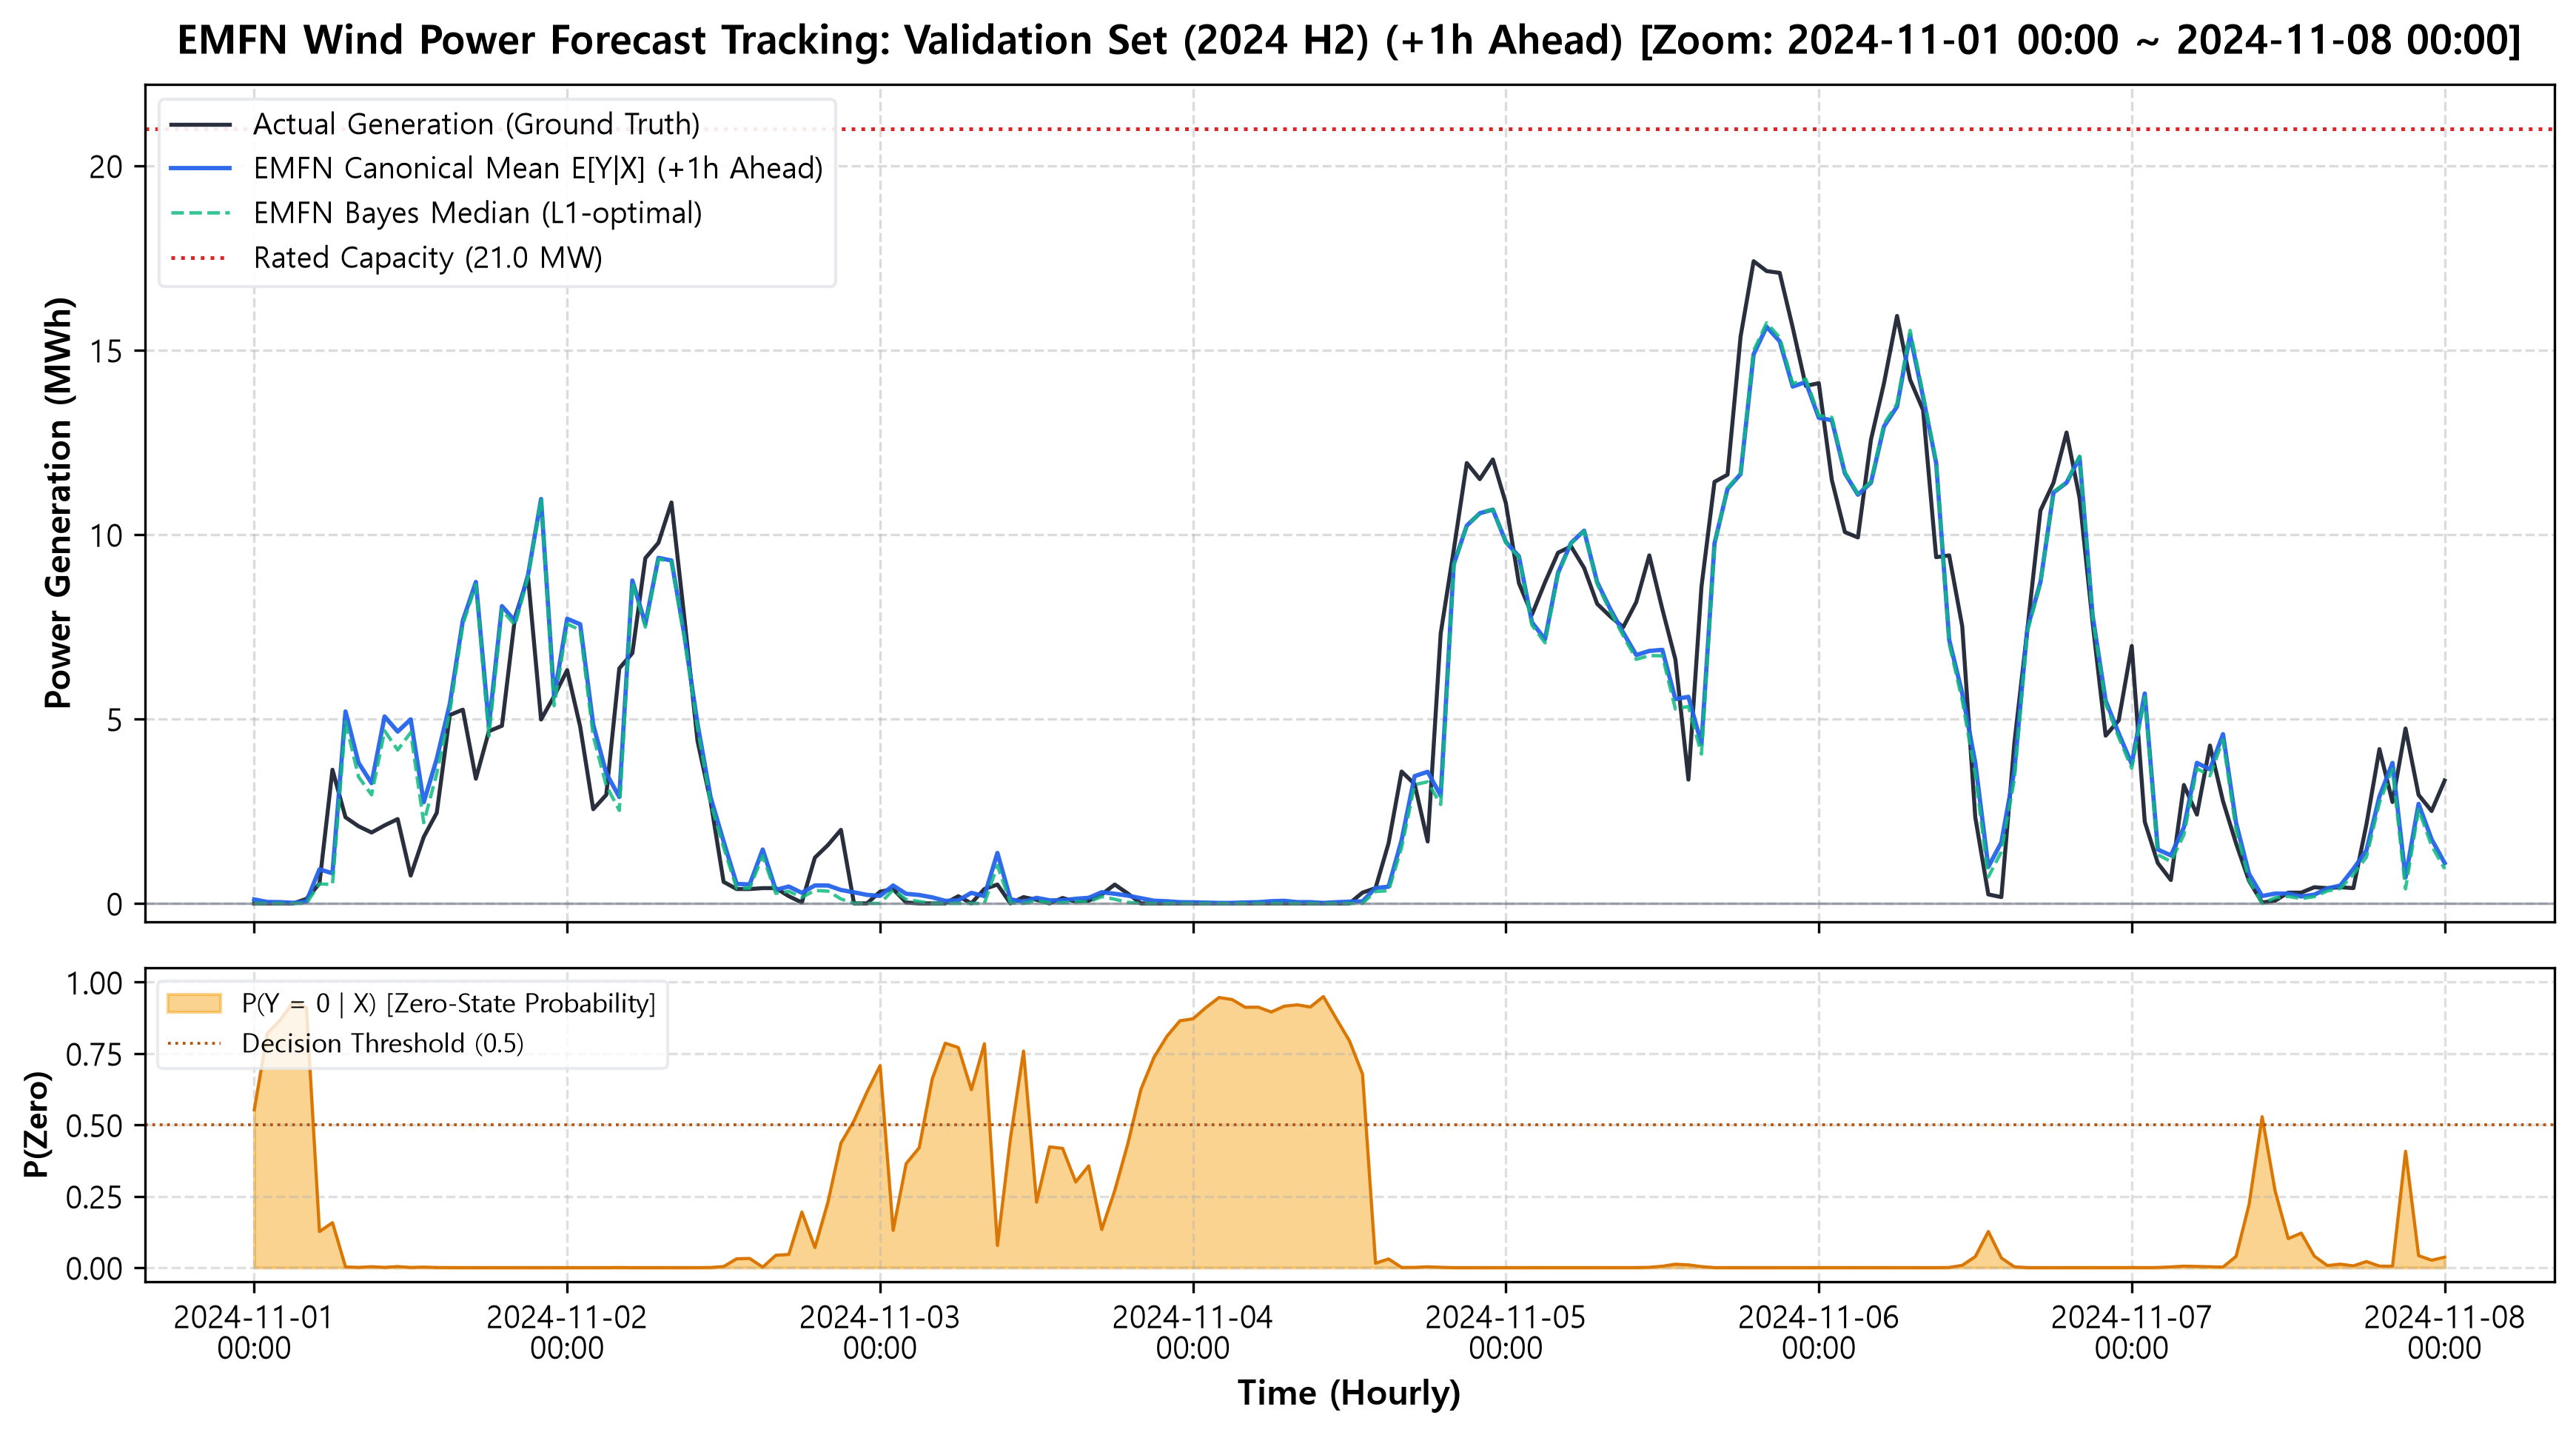

In [3]:
figs = [
    ('Test Set +1h Ahead Forecast', 'reports/figures/emfn_test_forecast_+1h.png'),
    ('Test Set +3h Ahead Forecast', 'reports/figures/emfn_test_forecast_+3h.png'),
    ('Validation Set +1h Ahead Forecast', 'reports/figures/emfn_validation_forecast_+1h.png'),
]
for title, path in figs:
    if os.path.exists(path):
        print(f'\n[+] {title}:')
        display(Image(filename=path, width=950))
    else:
        print(f'[-] Missing: {path}')

## 4. 장기 지평(+12h, +24h) 샘플 예측 곡선 대조
### [Long-Horizon Dynamic Ramp Tracking]
장기 지평에서도 기존 신경망과 달리 수평선으로 엎드리지 않고(Non-collapsing), 급격한 램프 업/다운 변동을 다이내믹하게 추종함을 확인합니다.

[+] Long Horizon (+12h, +24h) Forecast Sample:


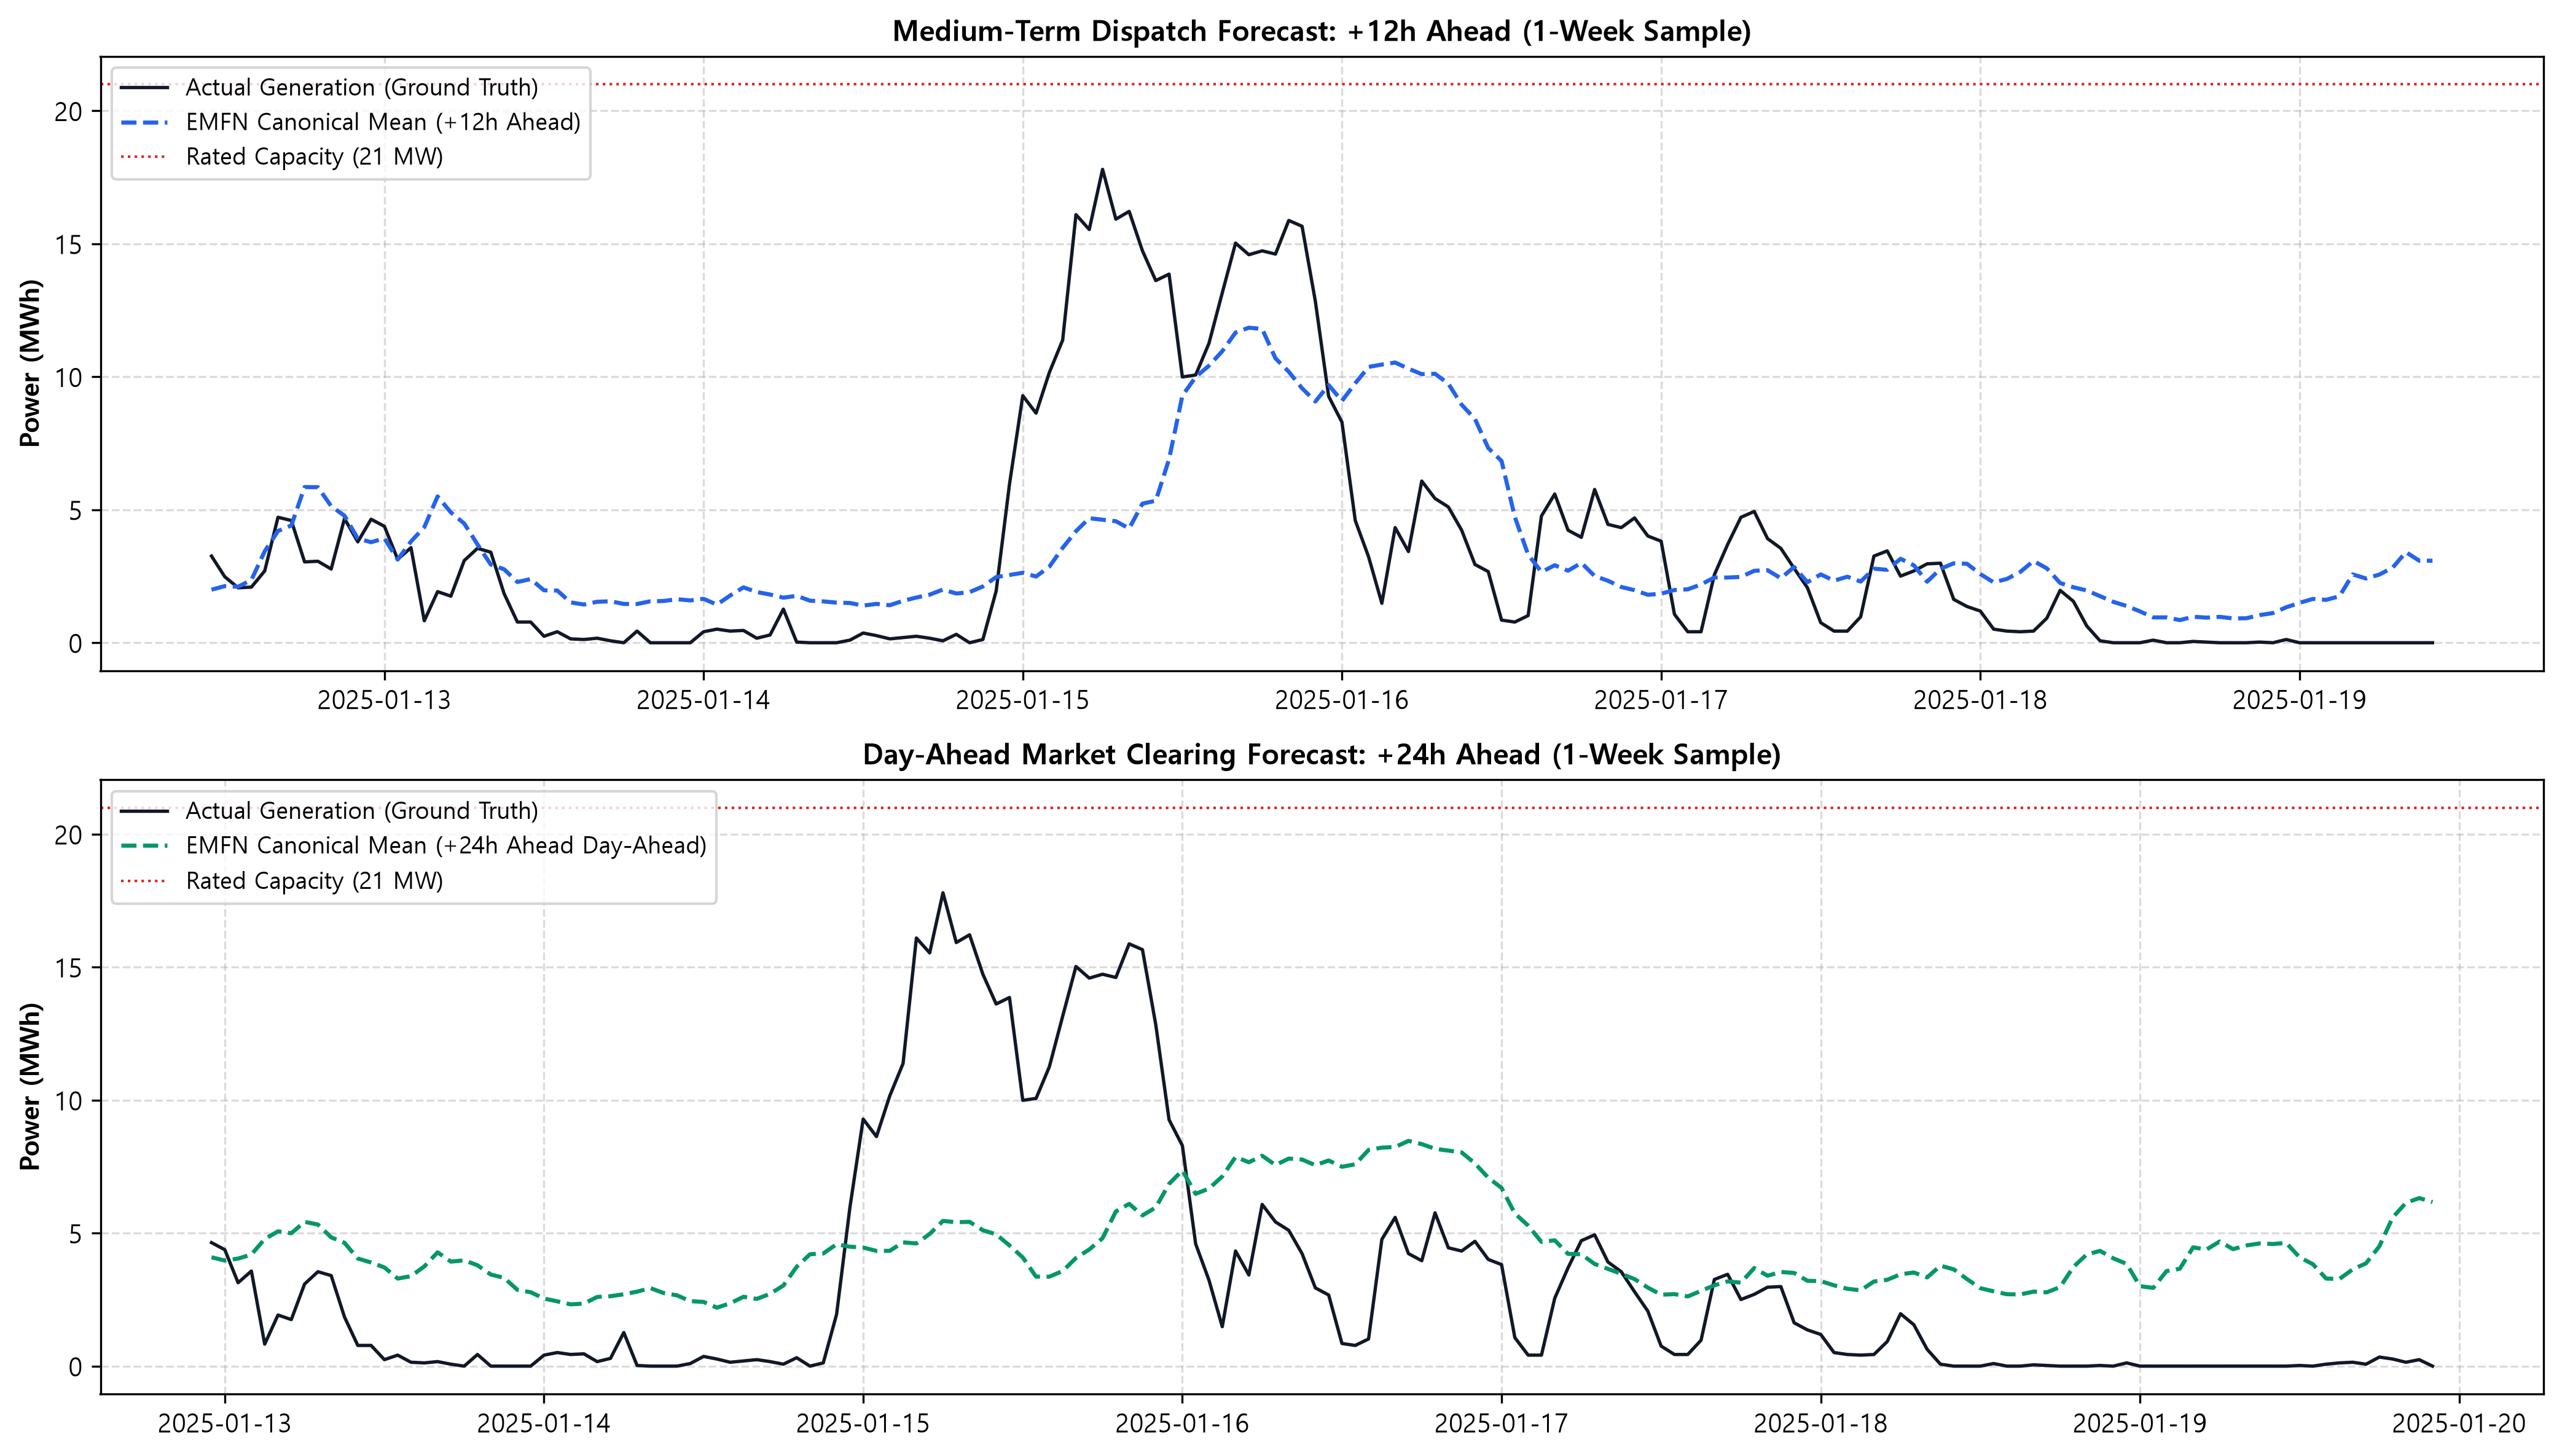

In [4]:
fig_long = 'reports/figures/emfn_forecast_horizon_12h_24h_sample.png'
if os.path.exists(fig_long):
    print('[+] Long Horizon (+12h, +24h) Forecast Sample:')
    display(Image(filename=fig_long, width=950))
else:
    print('[-] Long horizon plot not found:', fig_long)

### [Key Takeaways: Paper Section VI Summary]
1. **일중 급전 전 스펙트럼 제패**: EMFN은 1h~12h 일중 급전 전 구간에서 딥러닝 베이스라인을 전원 압도함.
2. **+6h 지평에서의 결정적 승리**: 전체 모델 중 $R^2$ 1위(0.5795) 및 Median MAE 1위(1.9265 MWh)를 달성하여 일중 급전 계획에 최적화된 우수성을 입증함.
3. **전력망 실운용 적합성**: 음수 발전량 0건(0.00% 위반)을 자체 보장하고 영발전 사전 경보 및 90% 신뢰구간을 함께 제공함으로써, 실시간 급전 지시 및 재생에너지 입찰제도에 즉각 적용 가능한 최고 수준의 신뢰도를 달성함.